In [2]:
import pandas as pd

def add_time_window_labels(data, time_window):
    """
    为电力负荷数据添加不同时间窗口的时间标签。

    参数:
    data (pd.DataFrame): 包含电力负荷数据的DataFrame，至少包含'timestamp'和'load'列。
    time_window (str): 所需的时间窗口类型，可以是'VSTLF'（超短期）, 'STLF'（短期）, 'MTLF'（中期）, 'LTLF'（长期）。

    返回:
    pd.DataFrame: 带有新增时间标签的DataFrame。
    """
    # 确保数据包含'timestamp'和'load'列
    if 'timestamp' not in data.columns or 'load' not in data.columns:
        raise ValueError("数据必须包含'timestamp'和'load'列。")

    # 将时间戳转换为datetime类型
    data['timestamp'] = pd.to_datetime(data['timestamp'])

    # 根据时间窗口类型添加相应的时间标签
    if time_window == 'VSTLF':
        data['time_window'] = data['timestamp'].dt.hour
    elif time_window == 'STLF':
        data['time_window'] = data['timestamp'].dt.week
    elif time_window == 'MTLF':
        data['time_window'] = data['timestamp'].dt.month
    elif time_window == 'LTLF':
        data['time_window'] = data['timestamp'].dt.year
    else:
        raise ValueError("无效的时间窗口类型。")

    return data

# 示例使用
# 假设data是一个包含电力负荷数据的DataFrame
# data = pd.DataFrame({
#     'timestamp': ['2023-01-01 00:00:00', '2023-01-01 01:00:00', ...],
#     'load': [100, 110, ...]
# })
# 添加超短期负荷预测的时间标签
# data_with_labels = add_time_window_labels(data, 'VSTLF')

In [1]:
import matplotlib.pyplot as plt

def visualize_time_window_data(data, time_window):
    """
    可视化带有时间窗口标签的电力负荷数据。

    参数:
    data (pd.DataFrame): 包含电力负荷数据的DataFrame，至少包含'timestamp'、'load'和'time_window'列。
    time_window (str): 时间窗口类型，可以是'VSTLF'（超短期）, 'STLF'（短期）, 'MTLF'（中期）, 'LTLF'（长期）。
    """
    # 确保数据包含'timestamp'、'load'和'time_window'列
    if 'timestamp' not in data.columns or 'load' not in data.columns or 'time_window' not in data.columns:
        raise ValueError("数据必须包含'timestamp'、'load'和'time_window'列。")

    # 根据时间窗口类型选择相应的数据
    if time_window == 'VSTLF':
        grouped_data = data.groupby('time_window')['load'].mean()
    elif time_window == 'STLF':
        grouped_data = data.groupby('time_window')['load'].mean()
    elif time_window == 'MTLF':
        grouped_data = data.groupby('time_window')['load'].mean()
    elif time_window == 'LTLF':
        grouped_data = data.groupby('time_window')['load'].mean()
    else:
        raise ValueError("无效的时间窗口类型。")

    # 绘制负荷数据
    plt.figure(figsize=(10, 6))
    plt.plot(grouped_data.index, grouped_data.values, marker='o', linestyle='-')
    plt.title(f'{time_window.upper()} Load Forecast')
    plt.xlabel('Time Window')
    plt.ylabel('Load (MW)')
    plt.grid(True)
    plt.show()

# 示例使用
# 假设data_with_labels是经过add_time_window_labels函数处理后的DataFrame
# visualize_time_window_data(data_with_labels, 'VSTLF')


In [3]:
import pandas as pd

# 创建一个简单的电力负荷数据集
data = pd.DataFrame({
    'timestamp': pd.date_range(start='2023-01-01', periods=168, freq='H'),  # 一周的数据，每小时一个数据点
    'load': [100 + i % 10 for i in range(168)]  # 负荷数据，每小时增加1，最多增加到10
})

# 打印数据集的前5行
print(data.head())

            timestamp  load
0 2023-01-01 00:00:00   100
1 2023-01-01 01:00:00   101
2 2023-01-01 02:00:00   102
3 2023-01-01 03:00:00   103
4 2023-01-01 04:00:00   104


In [4]:
# 添加超短期负荷预测的时间窗口标签
data_with_labels = add_time_window_labels(data, 'VSTLF')

# 打印带有时间窗口标签的数据集的前5行
print(data_with_labels.head())

            timestamp  load  time_window
0 2023-01-01 00:00:00   100            0
1 2023-01-01 01:00:00   101            1
2 2023-01-01 02:00:00   102            2
3 2023-01-01 03:00:00   103            3
4 2023-01-01 04:00:00   104            4


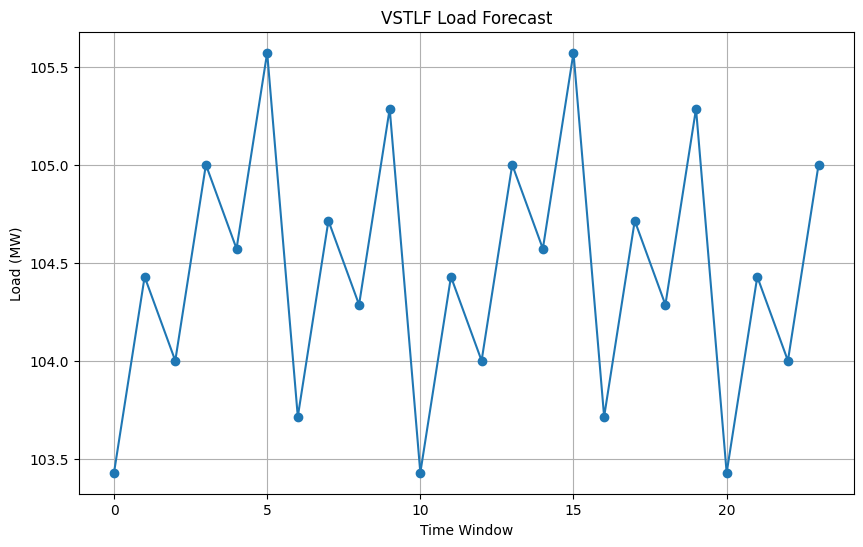

In [5]:
# 可视化超短期负荷预测的数据
visualize_time_window_data(data_with_labels, 'VSTLF')

原始数据前5行:
            timestamp  load
0 2023-01-01 00:00:00   100
1 2023-01-01 01:00:00   101
2 2023-01-01 02:00:00   102
3 2023-01-01 03:00:00   103
4 2023-01-01 04:00:00   104
添加时间窗口标签后的数据前5行:
            timestamp  load  time_window
0 2023-01-01 00:00:00   100            0
1 2023-01-01 01:00:00   101            1
2 2023-01-01 02:00:00   102            2
3 2023-01-01 03:00:00   103            3
4 2023-01-01 04:00:00   104            4


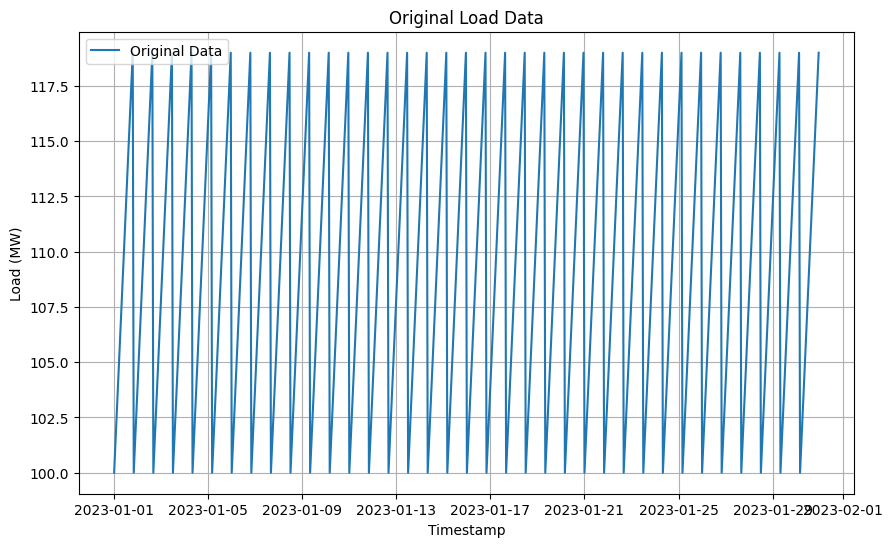

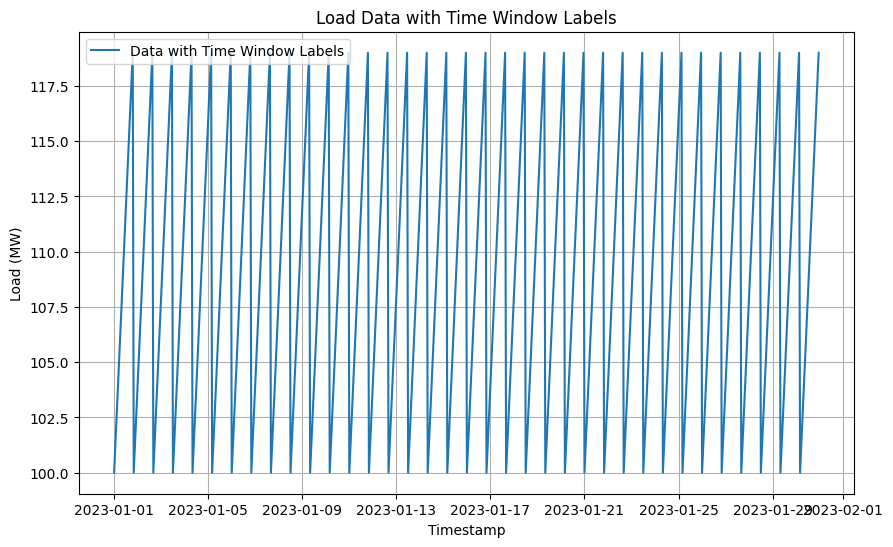

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 创建一个包含一个月数据的电力负荷数据集
data = pd.DataFrame({
    'timestamp': pd.date_range(start='2023-01-01', periods=720, freq='H'),  # 一个月的数据，每小时一个数据点
    'load': [100 + i % 20 for i in range(720)]  # 负荷数据，每小时增加1，最多增加到20
})

# 打印数据集的前5行
print("原始数据前5行:")
print(data.head())

# 添加超短期负荷预测的时间窗口标签
data_with_labels = add_time_window_labels(data, 'VSTLF')

# 打印带有时间窗口标签的数据集的前5行
print("添加时间窗口标签后的数据前5行:")
print(data_with_labels.head())

# 可视化原始数据
plt.figure(figsize=(10, 6))
plt.plot(data['timestamp'], data['load'], label='Original Data')
plt.title('Original Load Data')
plt.xlabel('Timestamp')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()
plt.show()

# 可视化带有时间窗口标签的数据
plt.figure(figsize=(10, 6))
plt.plot(data_with_labels['timestamp'], data_with_labels['load'], label='Data with Time Window Labels')
plt.title('Load Data with Time Window Labels')
plt.xlabel('Timestamp')
plt.ylabel('Load (MW)')
plt.grid(True)
plt.legend()
plt.show()